# Assignment 2

## Statement of AI use

Claude was used with debugging and fixing errors. Also to check parts of code and SQL queries. I wrote, tested, and reviewed the final notebook myself, and I verified the outputs before submission.

## Task 0: Dataset exploration for course project

### a) Dataset

Dataset: Stock data for the top 10 global companies from january 2015 to august 2024. 
Source: Kaggle, https://www.kaggle.com/datasets/umerhaddii/top-10-global-companies-stock-data-2024

### b) Dataset Description

My dataset contains daily historical stock price data for the 10 largest companies in the world in the year 2024, ranked by market capitalisation. After exclusion of two stocks, the dataset has **21879** rows, **8** columns and 0 missing values.

**Included variables:**
- date
- ticker
- open price 
- highest price 
- lowest price
- closing price
- adjusted closing price 
- volume.

**Companies included:** AAPL (Apple), MSFT (Microsoft), NVDA (Nvidia), GOOGL (Alphabet), AMZN (Amazon), META (Meta), BRK-B (Berkshire Hathaway), LLY (Eli Lilly), TSM (TSMC). In total we have 9 companies.

**Companies (stocks) excluded:** I excluded Saudi Aramco because it is listed on a foreign exchange and is therefore hard to compare and irrelevant to my analysis. Also excluded Google class C stock (GOOG ticker), since we already have Google class A stock (GOOGL) in the dataset. 

**Project plan:** This Kaggle dataset will be my primary data source for this stock market analysis project. After pulling this data, my plan is to:

1. Perform exploratory data analysis on price trends, returns, and volatility
2. Enrich the data with financial fundamentals (P/E, EPS, margins) through an API
3. Pull news headlines with an API and score sentiment 
4. Test if news sentiment correlates with stock returns
5. Build a simple model to predict next-day returns 

### c) Doing some exploratory data analysis on our dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Plot styling. I tried to do a cool green design with color codes because why not. 
sns.set_theme(style='darkgrid')

plt.rcParams.update({
    'figure.dpi':        120,
    'figure.facecolor':  '#0d1f0f',   
    'axes.facecolor':    '#122714',   
    'axes.edgecolor':    '#4caf50',   
    'axes.labelcolor':   '#c8e6c9',   
    'axes.titlecolor':   '#ffffff',   
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.grid':         True,
    'grid.color':        '#1e3d20',   
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'xtick.color':       '#a5d6a7',
    'ytick.color':       '#a5d6a7',
    'text.color':        '#c8e6c9',
    'legend.facecolor':  '#0d1f0f',
    'legend.edgecolor':  '#4caf50',
    'legend.labelcolor': '#c8e6c9',
    'figure.figsize':    (13, 6),
    'lines.linewidth':   2.0,
    'font.family':       'monospace',  
})

In [2]:
# Loading kaggle dataset and removing Saudi Aramco and Googles class C stock (GOOG ticker)
df_raw = pd.read_csv('top_10_stock_data.csv', parse_dates=['Date'])
df = df_raw[~df_raw['Ticker'].isin(['2222.SR', 'GOOG'])].copy()  
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Tickers: {sorted(df["Ticker"].unique())}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Missing values: {df.isna().sum().sum()}')
display(df.head())

Shape: (21879, 8)
Tickers: ['AAPL', 'AMZN', 'BRK-B', 'GOOGL', 'LLY', 'META', 'MSFT', 'NVDA', 'TSM']
Date range: 2015-01-02 to 2024-08-29
Missing values: 0


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,AAPL,27.847500,27.860001,26.837500,27.332500,24.373959,212818400
1,2015-01-05,AAPL,27.072500,27.162500,26.352501,26.562500,23.687313,257142000
2,2015-01-06,AAPL,26.635000,26.857500,26.157499,26.565001,23.689535,263188400
3,2015-01-07,AAPL,26.799999,27.049999,26.674999,26.937500,24.021711,160423600
4,2015-01-08,AAPL,27.307501,28.037500,27.174999,27.972500,24.944679,237458000


In [3]:
# Summary statistics for closing prices grouped by ticker
print('Summary Statistics: Closing Price (USD) by Ticker')
display(df.groupby('Ticker')['Close'].describe().round(2))

Summary Statistics: Closing Price (USD) by Ticker


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,2431.0,91.59,61.07,22.58,36.64,60.79,148.94,234.82
AMZN,2431.0,97.79,51.74,14.35,47.88,93.41,148.38,200.00
BRK-B,2431.0,233.77,80.30,124.13,169.90,208.94,290.21,468.37
GOOGL,2431.0,79.63,41.15,24.85,46.98,62.30,114.77,191.18
LLY,2431.0,218.95,201.65,65.97,82.77,123.06,286.32,954.48
META,2431.0,209.93,103.93,74.05,133.85,180.82,269.42,539.91
MSFT,2431.0,179.39,116.53,40.29,69.41,141.07,271.50,467.56
NVDA,2431.0,16.92,25.03,0.48,3.38,6.26,19.31,135.58
TSM,2431.0,66.17,39.51,18.76,35.24,48.75,96.38,191.05


In [4]:
# Computing daily returns and 20-day rolling volatility per ticker
# Also Summary stats for daily returns by ticker
df['Daily_Return'] = df.groupby('Ticker')['Close'].pct_change()
df['Volatility_20d'] = (
    df.groupby('Ticker')['Daily_Return']
    .transform(lambda x: x.rolling(20, min_periods=5).std()) * (252 ** 0.5)  # annualised
)

print('Summary Statistics: Daily Returns by Ticker')
display(df.groupby('Ticker')['Daily_Return'].describe().round(4))

Summary Statistics: Daily Returns by Ticker


,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,2430.0,0.0010,0.0181,-0.1286,-0.0075,0.0009,0.0101,0.1198
AMZN,2430.0,0.0012,0.0207,-0.1405,-0.0087,0.0011,0.0112,0.1413
BRK-B,2430.0,0.0005,0.0122,-0.0959,-0.0054,0.0005,0.0067,0.1161
GOOGL,2430.0,0.0009,0.0179,-0.1163,-0.0074,0.0012,0.0095,0.1626
LLY,2430.0,0.0012,0.0175,-0.1051,-0.0071,0.0010,0.0090,0.1568
META,2430.0,0.0011,0.0238,-0.2639,-0.0092,0.0010,0.0123,0.2328
MSFT,2430.0,0.0010,0.0172,-0.1474,-0.0069,0.0009,0.0098,0.1422
NVDA,2430.0,0.0027,0.0308,-0.1876,-0.0124,0.0026,0.0176,0.2981
TSM,2430.0,0.0010,0.0200,-0.1403,-0.0099,0.0008,0.0111,0.1265


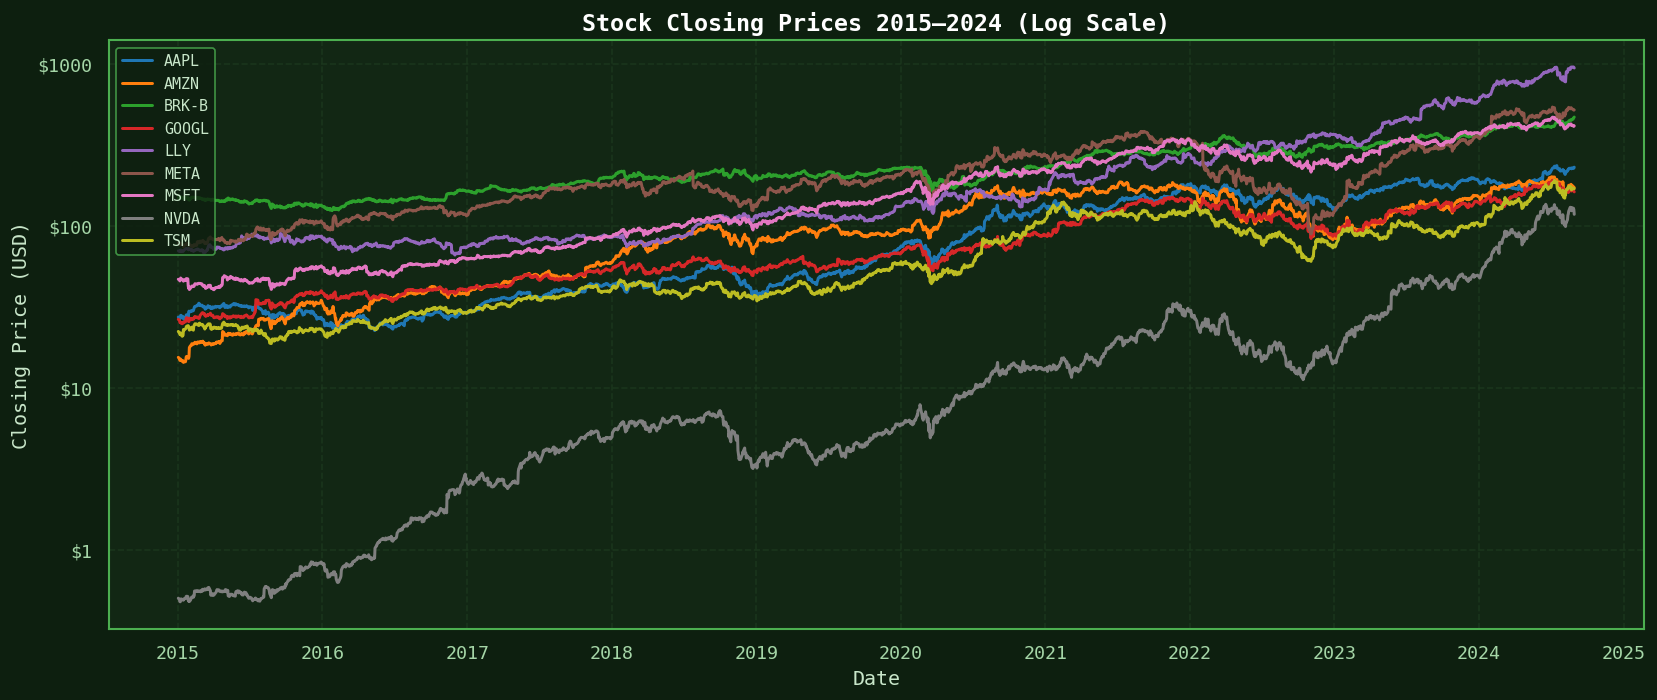

In [5]:
# Visualisation 1: Stock closing prices over time (log scale)
# Log scale makes all stocks visible and comparable despite huge differences in price levels

TICKERS = sorted(df['Ticker'].unique())
palette = sns.color_palette('tab10', len(TICKERS))

fig, ax = plt.subplots(figsize=(14, 6))

for ticker, color in zip(TICKERS, palette):
    subset = df[df['Ticker'] == ticker].sort_values('Date')
    ax.plot(subset['Date'], subset['Close'], label=ticker, linewidth=1.8, color=color)

ax.set_yscale('log')
ax.set_title('Stock Closing Prices 2015–2024 (Log Scale)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price (USD)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y:.0f}'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

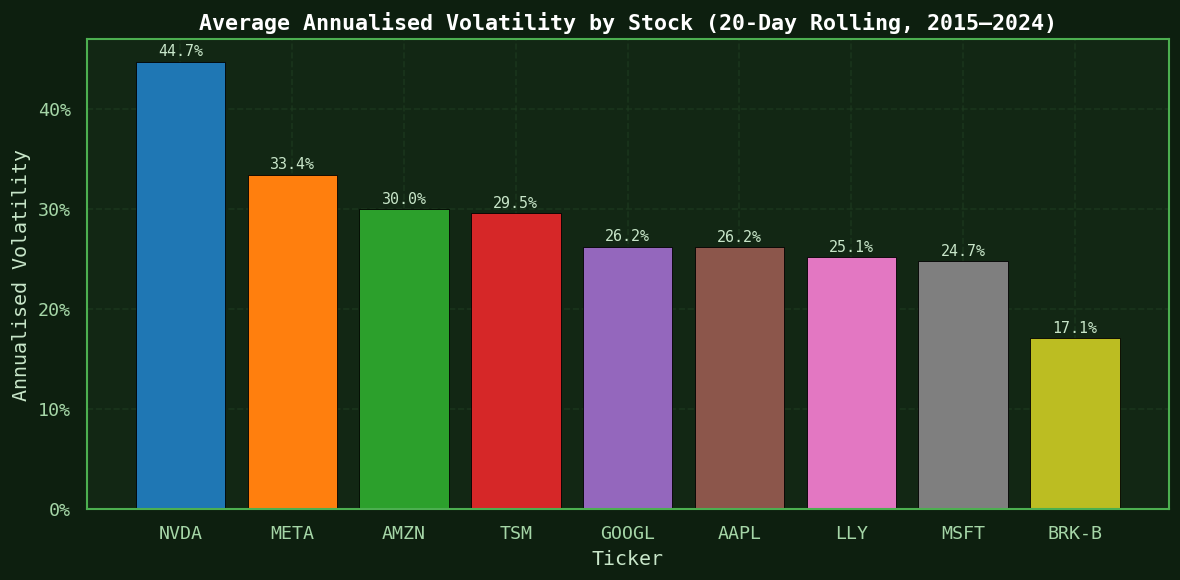

In [6]:
# Visualisation 2: Average annualised volatility by stock 
# Higher volatility = more price swings and risk 

vol_summary = (
    df.groupby('Ticker')['Volatility_20d']
    .mean()
    .dropna()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    vol_summary['Ticker'],
    vol_summary['Volatility_20d'],
    color=sns.color_palette('tab10', len(vol_summary)),
    edgecolor='black', linewidth=0.5
)

# Annotate each bar with its value
for bar, val in zip(bars, vol_summary['Volatility_20d']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9)

ax.set_title('Average Annualised Volatility by Stock (20-Day Rolling, 2015–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ticker')
ax.set_ylabel('Annualised Volatility')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

## Task 1 API key and .env file

In [7]:
# I created a .env file with an API key from marketstack and then created .gitignore, where .env will be hidden from GitHub
# Loading API key into the notebook, without showing the whole key 
import os
from dotenv import load_dotenv

load_dotenv()  

api_key = os.getenv('MARKETSTACK_API_KEY')

# Print only first 5 characters to confirm it loaded 
print(f'API key loaded: {api_key[:5]}...')

API key loaded: f5fb6...


## Task 2

### a)

In [8]:
# Retrieving the data 
import requests
import time

FAANG_TICKERS = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']
BASE_URL = 'http://api.marketstack.com/v1/eod'

all_records = []

for ticker in FAANG_TICKERS:
    print(f'Fetching {ticker}...')
    params = {
        'access_key': api_key,
        'symbols': ticker,
        'date_from': '2026-03-01',
        'date_to': '2026-03-31',
        'limit': 50
    }
    response = requests.get(BASE_URL, params=params)
    data = response.json()

    if 'data' in data and data['data']:
        all_records.extend(data['data'])
        print(f'  -> Got {len(data["data"])} records')
    else:
        print(f'  -> No data returned: {data.get("error", data)}')

    time.sleep(0.5)  # doing this to not spam the server with requests too fast

print(f'\nTotal records fetched: {len(all_records)}')

Fetching META...
  -> Got 22 records
Fetching AAPL...
  -> Got 22 records
Fetching AMZN...
  -> Got 22 records
Fetching NFLX...
  -> Got 22 records
Fetching GOOG...
  -> Got 22 records

Total records fetched: 110


### b)

In [9]:
# Converting JSON records to a pandas DataFrame
stocks_df = pd.DataFrame(all_records)

# Keeping relevant columns and parse dates
stocks_df = stocks_df[['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']].copy()
stocks_df['date'] = pd.to_datetime(stocks_df['date']).dt.date
stocks_df = stocks_df.sort_values(['symbol', 'date']).reset_index(drop=True)

print('Shape:', stocks_df.shape)
display(stocks_df.head())

Shape: (110, 7)


,symbol,date,open,high,low,close,volume
0,AAPL,2026-03-02,262.440,266.530,260.20,264.72,41576035.0
1,AAPL,2026-03-03,263.480,265.560,260.13,263.75,37994695.0
2,AAPL,2026-03-04,264.650,266.150,261.42,262.52,39258957.0
3,AAPL,2026-03-05,260.745,261.555,257.25,260.29,49424671.0
4,AAPL,2026-03-06,258.740,258.760,254.37,257.46,40628988.0


### c)

In [10]:
# Summary stats for closing prices grouped by stock
print('Closing Price Summary Statistics (March 2026)')
display(stocks_df.groupby('symbol')['close'].describe().round(2))

# Calculating return percentage: (last_close - first_close) / first_close * 100
first_last = stocks_df.sort_values('date').groupby('symbol')['close'].agg(['first', 'last'])
returns = ((first_last['last'] - first_last['first']) / first_last['first'] * 100).round(2).reset_index()
returns.columns = ['symbol', 'return_pct']
returns = returns.sort_values('return_pct', ascending=False).reset_index(drop=True)

print('\nMarch 2026 Return (%) by Stock')
display(returns)

best = returns.iloc[0]
worst = returns.iloc[-1]
print(f'\nBest performer:  {best["symbol"]} ({best["return_pct"]:+.2f}%)')
print(f'Worst performer: {worst["symbol"]} ({worst["return_pct"]:+.2f}%)')
# Rough month for FAANG stocks, Amazon performing the best with a -0,06 % loss and META getting hit the hardest with -12,46 %

Closing Price Summary Statistics (March 2026)


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.91,5.51,246.63,250.46,253.34,260.19,264.72
AMZN,22.0,210.00,4.64,199.34,207.82,209.70,213.07,218.94
GOOG,22.0,297.98,10.93,273.14,291.77,302.33,305.94,309.41
META,22.0,614.99,41.31,525.72,593.97,619.17,652.02,667.73
NFLX,22.0,95.08,2.51,90.92,93.34,94.80,97.05,99.17



March 2026 Return (%) by Stock


,symbol,return_pct
0,AMZN,-0.06
1,NFLX,-0.97
2,AAPL,-4.13
3,GOOG,-6.37
4,META,-12.46



Best performer:  AMZN (-0.06%)
Worst performer: META (-12.46%)


## Task 3: Visualization

### a)

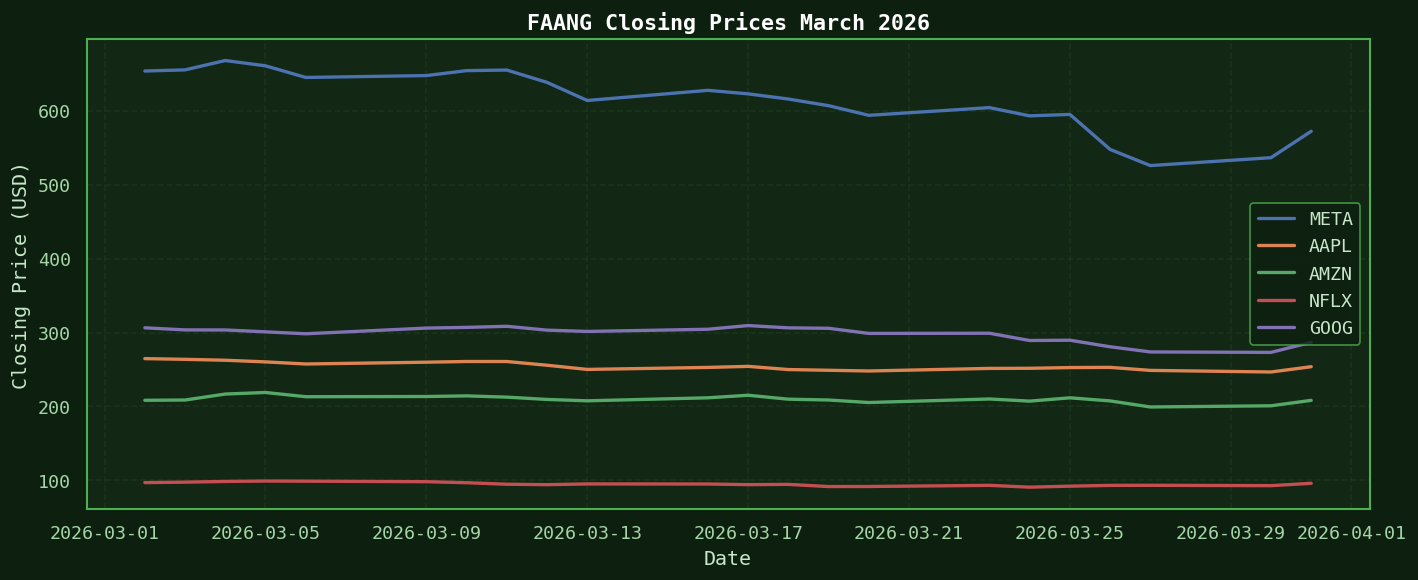

In [11]:
# Line chart showing the closing price of each stock in March 2026
fig, ax = plt.subplots(figsize=(12, 5))

for ticker in FAANG_TICKERS:
    subset = stocks_df[stocks_df['symbol'] == ticker].sort_values('date')
    ax.plot(subset['date'], subset['close'], label=ticker, linewidth=2)

ax.set_title('FAANG Closing Prices March 2026', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

### b)

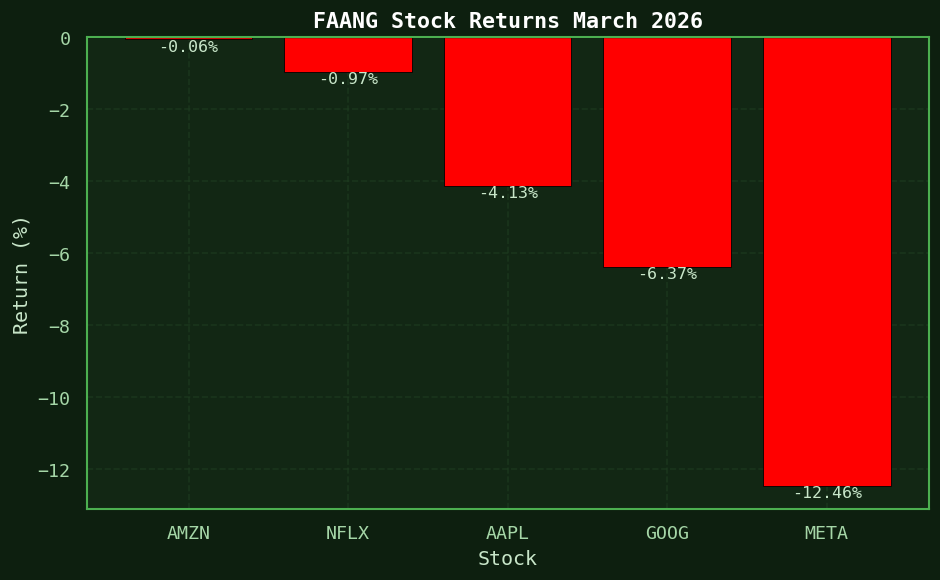

In [12]:
# Bar plot showing the overall return percentage in March 2026 for the FAANG stocks 
# Remember that all returns are negative 
colors = ['green' if r >= 0 else 'red' for r in returns['return_pct']]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(returns['symbol'], returns['return_pct'], color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, returns['return_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.1 if val >= 0 else -0.4),
            f'{val:+.2f}%', ha='center', va='bottom', fontsize=10)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('FAANG Stock Returns March 2026', fontsize=13, fontweight='bold')
ax.set_xlabel('Stock')
ax.set_ylabel('Return (%)')
plt.tight_layout()
plt.show()

### c)

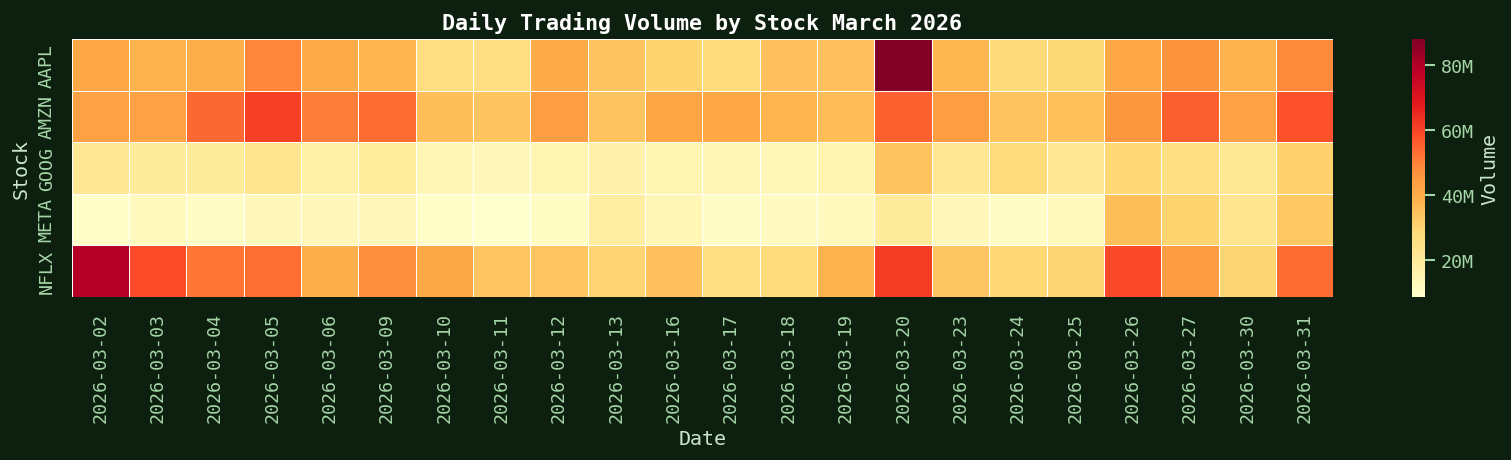

In [13]:
# Heatmap of for the daily trading volume of all stocks 
volume_pivot = stocks_df.pivot(index='symbol', columns='date', values='volume')

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    volume_pivot,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Volume', 'format': lambda x, _: f'{x/1e6:.0f}M'},
    linewidths=0.3
)
ax.set_title('Daily Trading Volume by Stock March 2026', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Stock')
plt.tight_layout()
plt.show()

## Task 4: JSON export

### a) and b)

In [14]:
import json
import os

os.makedirs('exports', exist_ok=True)

# Task 4a Export raw JSON records
with open('exports/stockdata.json', 'w') as f:
    json.dump(all_records, f, indent=2, default=str)
print('Exported stockdata.json')

# Task 4b Export DataFrame as CSV
stocks_df.to_csv('exports/stockdata.csv', index=False)
print('Exported stockdata.csv')

Exported stockdata.json
Exported stockdata.csv


### c)

In [15]:
# Load JSON
with open('exports/stockdata.json', 'r') as f:
    json_reloaded = json.load(f)
df_from_json = pd.DataFrame(json_reloaded)[['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']]
df_from_json['date'] = pd.to_datetime(df_from_json['date']).dt.date
df_from_json = df_from_json.sort_values(['symbol', 'date']).reset_index(drop=True)
print('Reloaded from JSON')
display(df_from_json.head())

# Verify JSON matches the original
print('JSON matches original DataFrame:', df_from_json.reset_index(drop=True).equals(stocks_df.reset_index(drop=True)))

# Load CSV
df_from_csv = pd.read_csv('exports/stockdata.csv', parse_dates=['date'])
df_from_csv['date'] = df_from_csv['date'].dt.date
print('Reloaded from CSV')
display(df_from_csv.head())

# Verify CSV matches the original
print('CSV matches original DataFrame:', df_from_csv.reset_index(drop=True).equals(stocks_df.reset_index(drop=True)))

Reloaded from JSON


,symbol,date,open,high,low,close,volume
0,AAPL,2026-03-02,262.440,266.530,260.20,264.72,41576035.0
1,AAPL,2026-03-03,263.480,265.560,260.13,263.75,37994695.0
2,AAPL,2026-03-04,264.650,266.150,261.42,262.52,39258957.0
3,AAPL,2026-03-05,260.745,261.555,257.25,260.29,49424671.0
4,AAPL,2026-03-06,258.740,258.760,254.37,257.46,40628988.0


JSON matches original DataFrame: True
Reloaded from CSV


,symbol,date,open,high,low,close,volume
0,AAPL,2026-03-02,262.440,266.530,260.20,264.72,41576035.0
1,AAPL,2026-03-03,263.480,265.560,260.13,263.75,37994695.0
2,AAPL,2026-03-04,264.650,266.150,261.42,262.52,39258957.0
3,AAPL,2026-03-05,260.745,261.555,257.25,260.29,49424671.0
4,AAPL,2026-03-06,258.740,258.760,254.37,257.46,40628988.0


CSV matches original DataFrame: True


## Task 5: Querying the Northwind database

In [16]:
# Northwind SQLite downloaded and put to my assignment2 folder
import sqlite3
import pandas as pd

# Connect to the Northwind SQLite database
conn = sqlite3.connect('northwind.db')

### a)

In [17]:
# List all tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
print('Tables in Northwind Database')
display(tables)

Tables in Northwind Database


,name
0,Categories
1,CustomerCustomerDemo
2,CustomerDemographics
3,Customers
4,EmployeeTerritories
5,Employees
6,Order Details
7,Orders
8,Products
9,Regions


### b)

In [18]:
# SQL query for Products with unit price above 30
query_5b = """
    SELECT ProductName, UnitPrice, UnitsInStock
    FROM Products
    WHERE UnitPrice > 30
"""

df_5b = pd.read_sql(query_5b, conn)
print(f'Products with UnitPrice > 30: {len(df_5b)} products')
display(df_5b)

Products with UnitPrice > 30: 24 products


,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


### c)

In [19]:
# Orders shipped to Germany with line totals
query_5c = """
    SELECT c.CompanyName,
           o.OrderID,
           o.OrderDate,
           o.ShipCountry,
           od.UnitPrice * od.Quantity AS LineTotal
    FROM Orders o
    JOIN Customers c ON o.CustomerID = c.CustomerID
    JOIN 'Order Details' od ON o.OrderID = od.OrderID
    WHERE o.ShipCountry = 'Germany'
"""
df_5c = pd.read_sql(query_5c, conn)
print(f'Orders shipped to Germany: {len(df_5c)} line items')
display(df_5c)

Orders shipped to Germany: 80673 line items


,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


## Task 6: Visualizing the Northwind data

### a)

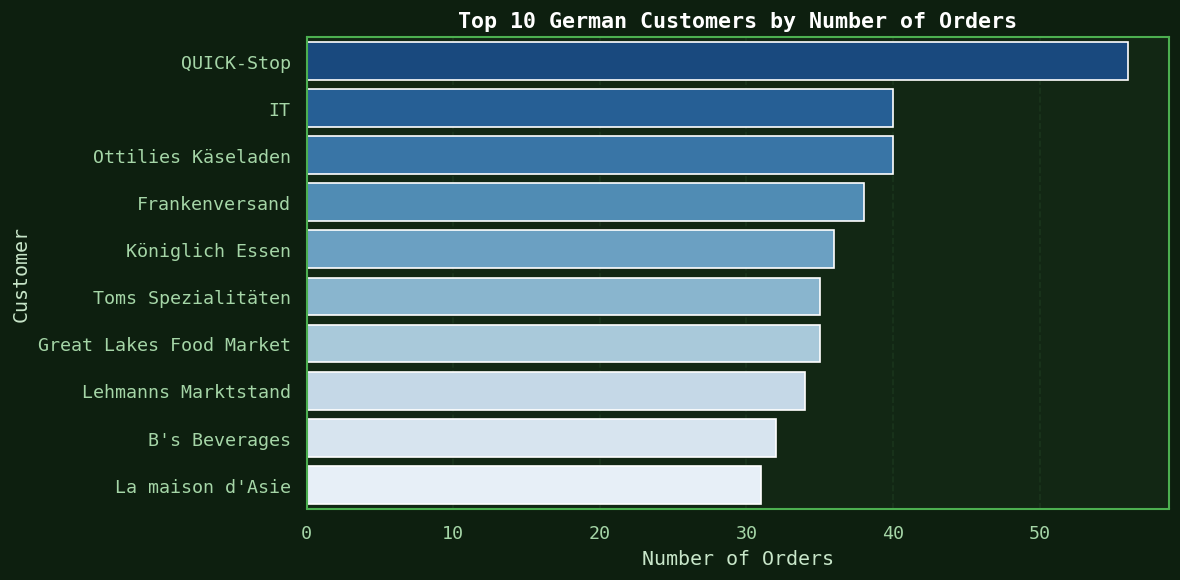

In [20]:
# Bar plot for orders per customer 
orders_per_customer = (
    df_5c.groupby('CompanyName')['OrderID']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
orders_per_customer.columns = ['CompanyName', 'OrderCount']

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=orders_per_customer, x='OrderCount', y='CompanyName', hue='CompanyName', palette='Blues_r', ax=ax, legend=False)
ax.set_title('Top 10 German Customers by Number of Orders', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Customer')
plt.tight_layout()
plt.show()

### b)

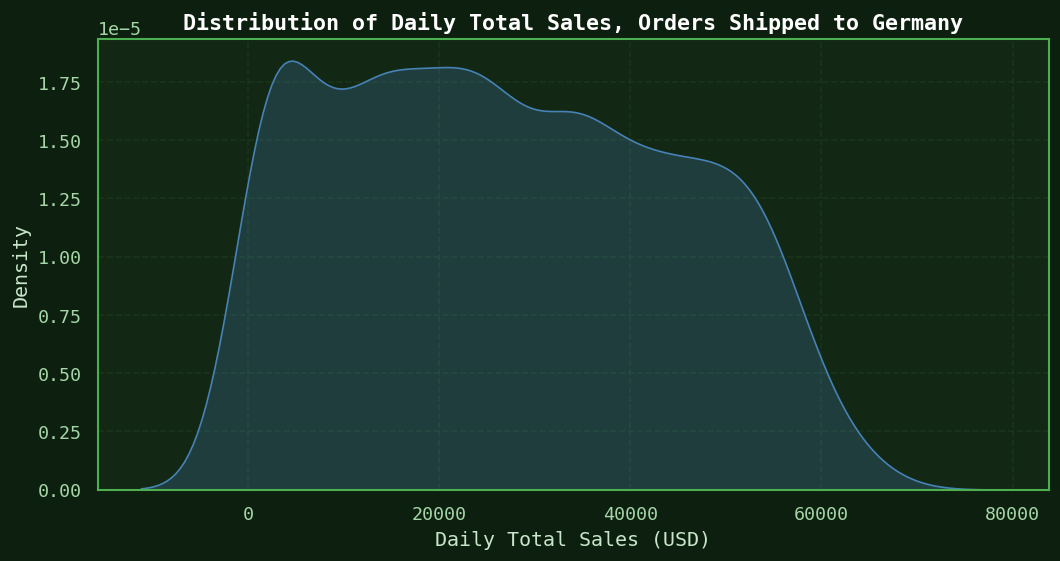

In [21]:
# Density plot 
daily_sales = df_5c.groupby('OrderDate')['LineTotal'].sum().reset_index()
daily_sales.columns = ['OrderDate', 'DailyTotal']

fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(data=daily_sales, x='DailyTotal', fill=True, color='steelblue', ax=ax)
ax.set_title('Distribution of Daily Total Sales, Orders Shipped to Germany', fontsize=13, fontweight='bold')
ax.set_xlabel('Daily Total Sales (USD)')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

### c)

,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Confections,66347544.94
2,Meat/Poultry,64896314.41
3,Dairy Products,58034940.00
4,Condiments,55802774.45
5,Seafood,49931965.52
6,Produce,32706403.90
7,Grains/Cereals,28573512.55


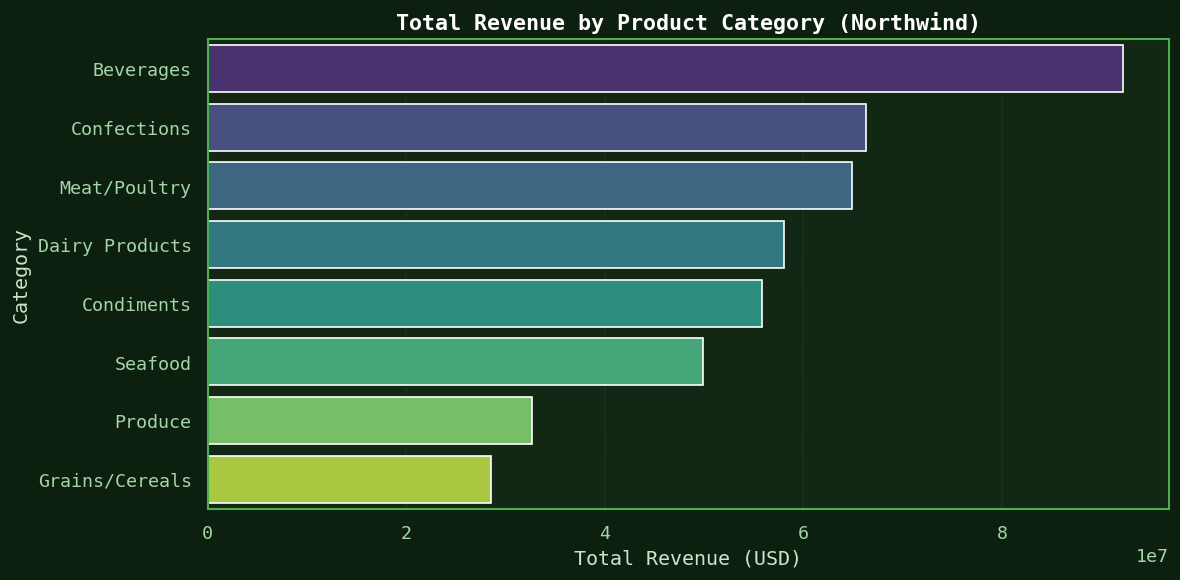

In [22]:
# Bar plot and SQL for total revenue per product category
query_6c = """
    SELECT cat.CategoryName,
           SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
    FROM 'Order Details' od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories cat ON p.CategoryID = cat.CategoryID
    GROUP BY cat.CategoryName
    ORDER BY TotalRevenue DESC
"""
df_6c = pd.read_sql(query_6c, conn)
display(df_6c)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_6c, x='TotalRevenue', y='CategoryName', hue='CategoryName', palette='viridis', ax=ax, legend=False)
ax.set_title('Total Revenue by Product Category (Northwind)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Revenue (USD)')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

## Task 7: Comparing Python to SQL

### a)

In [23]:
# Loading the full Products and Categories tables from the Northwind database into pandas DataFrames
df_products = pd.read_sql('SELECT * FROM Products', conn)
df_categories = pd.read_sql('SELECT * FROM Categories', conn)

print('Products (first 5 rows)')
display(df_products.head())

print('Categories (first 5 rows)')
display(df_categories.head())

Products (first 5 rows)


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


Categories (first 5 rows)


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


### b)

In [24]:
# Inner join on CategoryID for the two DataFrames in 7a
df_joined = df_products.merge(df_categories, on='CategoryID', how='inner')

print(f'Joined shape: {df_joined.shape}')
display(df_joined.head())

Joined shape: (77, 13)


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


### c)

In [25]:
import time

# Speed comparison: SQL join vs pandas join

# Method 1: Full SQL (as in Task 6c)
start = time.time()
df_sql_result = pd.read_sql(query_6c, conn)
sql_time = time.time() - start

# Method 2: Fetch tables via SQL, then join and aggregate with pandas
start = time.time()
df_od = pd.read_sql("SELECT * FROM 'Order Details'", conn)
df_prod = pd.read_sql('SELECT * FROM Products', conn)
df_cat = pd.read_sql('SELECT * FROM Categories', conn)
df_pandas_result = (
    df_od
    .merge(df_prod[['ProductID', 'CategoryID']], on='ProductID')
    .merge(df_cat[['CategoryID', 'CategoryName']], on='CategoryID')
    .assign(Revenue=lambda x: x['UnitPrice'] * x['Quantity'])
    .groupby('CategoryName', as_index=False)['Revenue']
    .sum()
    .sort_values('Revenue', ascending=False)
)
pandas_time = time.time() - start

print(f'SQL execution time:    {sql_time:.4f} seconds')
print(f'Pandas execution time: {pandas_time:.4f} seconds')
print()
print('SQL was faster. It only returns the final result, while pandas has to load entire tables into memory first before joining.')

SQL execution time:    1.0135 seconds
Pandas execution time: 1.7948 seconds

SQL was faster. It only returns the final result, while pandas has to load entire tables into memory first before joining.


## Task 8: Wide and Long Format

In [26]:
# Given datasets
wide_data = pd.DataFrame({
    'store': ['Helsinki', 'Tampere', 'Turku'],
    'Q1_sales': [12000, 8500, 9200],
    'Q2_sales': [13500, 9100, 9800],
    'Q3_sales': [11800, 8800, 10100],
    'Q4_sales': [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    'month': ['Jan', 'Jan', 'Feb', 'Feb', 'Mar', 'Mar'],
    'product': ['Laptop', 'Phone', 'Laptop', 'Phone', 'Laptop', 'Phone'],
    'units_sold': [45, 120, 50, 110, 55, 130]
})

### a)

In [27]:
# Converting from wide to long
print('wide_data BEFORE melt')
display(wide_data)

wide_melted = pd.melt(
    wide_data,
    id_vars='store',
    value_vars=['Q1_sales', 'Q2_sales', 'Q3_sales', 'Q4_sales'],
    var_name='quarter',
    value_name='sales'
)

print('wide_data AFTER melt (long format)')
display(wide_melted)

wide_data BEFORE melt


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


wide_data AFTER melt (long format)


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


### b)

In [28]:
# Converting from long to wide
print('long_data BEFORE pivot')
display(long_data)

long_pivoted = long_data.pivot(
    index='month',
    columns='product',
    values='units_sold'
).reset_index()
long_pivoted.columns.name = None  # clean up column name label

print('long_data AFTER pivot (wide format)')
display(long_pivoted)

long_data BEFORE pivot


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


long_data AFTER pivot (wide format)


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


### c)

In [29]:
# Converting back to original forms 
# Melt result back to wide (pivot)
wide_restored = wide_melted.pivot(
    index='store',
    columns='quarter',
    values='sales'
).reset_index()
wide_restored.columns.name = None
# Restore original column order
wide_restored = wide_restored[['store', 'Q1_sales', 'Q2_sales', 'Q3_sales', 'Q4_sales']]

print('wide_data restored from melted')
display(wide_restored)
print('Matches original:', wide_restored.reset_index(drop=True).equals(wide_data))

# Pivot result back to long (melt)
long_restored = pd.melt(
    long_pivoted,
    id_vars='month',
    value_vars=['Laptop', 'Phone'],
    var_name='product',
    value_name='units_sold'
).sort_values(['month', 'product']).reset_index(drop=True)

print('long_data restored from pivoted')
display(long_restored)
print('Matches original:', long_restored.equals(long_data.sort_values(['month', 'product']).reset_index(drop=True)))

wide_data restored from melted


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Matches original: True
long_data restored from pivoted


,month,product,units_sold
0,Feb,Laptop,50
1,Feb,Phone,110
2,Jan,Laptop,45
3,Jan,Phone,120
4,Mar,Laptop,55
5,Mar,Phone,130


Matches original: True
